# NeqSim parameter database: traceable fluid inputs without unsafe mutation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/PVT/parameter_database.ipynb)

**Audience.** Process, PVT, and flow-assurance engineers who need to inspect the
parameters behind a NeqSim fluid. Familiarity with Python, SI units, and cubic equations
of state is helpful.

**Prerequisites.** A clean Google Colab or Jupyter runtime with internet access only for
the first PyPI installation. The example uses no private files, credentials, or external
database server.

In [1]:
import importlib.util
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )

## Learning objectives and engineering context

After completing this tutorial, you can:

1. open NeqSim's packaged embedded database and confirm its provenance;
2. inspect component constants and binary-interaction parameters with read-only SQL;
3. reconcile database units with the values exposed by a live thermodynamic system;
4. explain how the binary parameter $k_{ij}$ affects an SRK mixture calculation; and
5. carry the database-backed model into a stream and compressor calculation.

Simulation results are only as defensible as their inputs. This workflow makes parameter
selection visible and testable while keeping the shared parameter store unchanged.

In [2]:
import platform
import subprocess
from importlib.metadata import version

import matplotlib.pyplot as plt
import neqsim
import numpy as np
import pandas as pd
from neqsim import jneqsim
from neqsim.process import clearProcess, compressor, runProcess, stream
from neqsim.thermo import TPflash


java_version = subprocess.run(
    ["java", "-version"],
    check=True,
    capture_output=True,
    text=True,
).stderr.splitlines()[0]

runtime_table = pd.DataFrame(
    {
        "runtime": ["NeqSim", "Python", "Java"],
        "version": [version("neqsim"), platform.python_version(), java_version],
    }
)
print(runtime_table.to_string(index=False))
runtime_table

runtime                              version
 NeqSim                               3.16.0
 Python                              3.12.13
   Java openjdk version "17.0.19" 2026-04-21


## From a database row to an engineering result

NeqSim ships an embedded H2 database containing component constants and model-specific
pair parameters. A thermodynamic system selects an equation of state, loads parameters,
adds composition and state, and solves a flash. A process stream then carries that state
into unit operations.

The data flow is:

**embedded database → fluid model → flash calculation → stream → unit operation → checks**

This notebook performs only hard-coded `SELECT` queries. It never calls database update
or table-replacement methods. That restriction is important in shared notebooks because a
write can silently change every later fluid created in the same runtime.

In [3]:
database = jneqsim.util.database.NeqSimDataBase()
database_type = str(database.getDataBaseType())
component_names = sorted(str(name) for name in database.getComponentNames())

database_overview = pd.DataFrame(
    {
        "item": ["database type", "available component names"],
        "value": [database_type, len(component_names)],
    }
)
database_overview

## Component parameters and units

For the packaged `COMP` table, critical temperature `TC` and normal boiling point
`NORMBOIL` are stored in degrees Celsius, critical pressure `PC` in bara, and
`MOLARMASS` in g/mol. We convert temperature to K and molar mass to kg/mol before
display. The acentric factor $\omega$ is dimensionless.

These constants enter the pure-component attraction and co-volume terms of a cubic
equation of state. The SRK pressure relation is

$$
P = \frac{RT}{v-b} - \frac{a\alpha}{v(v+b)}
$$

where $P$ is pressure in Pa, $T$ is temperature in K, $v$ is molar volume in
$\mathrm{m^3/mol}$, $R$ is the gas constant, and $a$, $b$, and $\alpha$ are model
parameters derived from critical properties and $\omega$.

In [4]:
selected_components = ["methane", "ethane", "propane", "CO2", "water"]
availability = pd.DataFrame(
    {
        "component": selected_components,
        "available": [database.hasComponent(name) for name in selected_components],
    }
)

assert availability["available"].all()
availability

## A small read-only query helper

The Java database API returns a JDBC `ResultSet`. The helper below immediately copies
selected columns into a pandas table. The query text and column list are defined in the
notebook; no user input is concatenated into SQL.

For production tools, use parameterized queries or a controlled data-access layer. Always
close database connections, especially in repeated notebook or service workflows.

In [5]:
def result_set_to_frame(result_set, columns):
    rows = []

    while result_set.next():
        row = {
            column: str(result_set.getString(column))
            for column in columns
        }
        rows.append(row)

    return pd.DataFrame(rows, columns=columns)


component_columns = [
    "NAME",
    "CASNUMBER",
    "FORMULA",
    "MOLARMASS",
    "TC",
    "PC",
    "ACSFACT",
    "NORMBOIL",
]
component_query = (
    "SELECT NAME, CASNUMBER, FORMULA, MOLARMASS, TC, PC, ACSFACT, NORMBOIL "
    "FROM comp WHERE NAME IN ('methane', 'ethane', 'propane', 'CO2', 'water')"
)
component_result = database.getResultSet(component_query)
component_raw = result_set_to_frame(component_result, component_columns)
component_raw

## Convert once, label every quantity

Database schemas often preserve historical engineering units. The safest practice is to
convert at the boundary, give columns explicit unit labels, and retain identifiers such as
CAS numbers. This avoids ambiguous values downstream and creates an auditable table for
reviews or model reports.

In [6]:
component_properties = component_raw.assign(
    **{
        "molar mass [kg/mol]": component_raw["MOLARMASS"].astype(float) / 1000.0,
        "critical temperature [K]": component_raw["TC"].astype(float) + 273.15,
        "critical pressure [bara]": component_raw["PC"].astype(float),
        "acentric factor [-]": component_raw["ACSFACT"].astype(float),
        "normal boiling point [K]": component_raw["NORMBOIL"].astype(float) + 273.15,
    }
)
component_properties = component_properties[
    [
        "NAME",
        "CASNUMBER",
        "FORMULA",
        "molar mass [kg/mol]",
        "critical temperature [K]",
        "critical pressure [bara]",
        "acentric factor [-]",
        "normal boiling point [K]",
    ]
].sort_values("critical temperature [K]")
component_properties.reset_index(drop=True, inplace=True)
component_properties.round(5)

## Interpret the component family

Critical temperature rises from methane toward heavier hydrocarbons, while water is
strongly associating and lies outside the main natural-gas trend. A cubic SRK model is a
practical baseline for dry gas and hydrocarbon processing, but aqueous or strongly polar
systems may require CPA or another association-aware model plus fitted interaction data.

The plot is a parameter audit, not a process operating envelope: critical points are
pure-component constants, whereas a mixture has its own phase envelope.

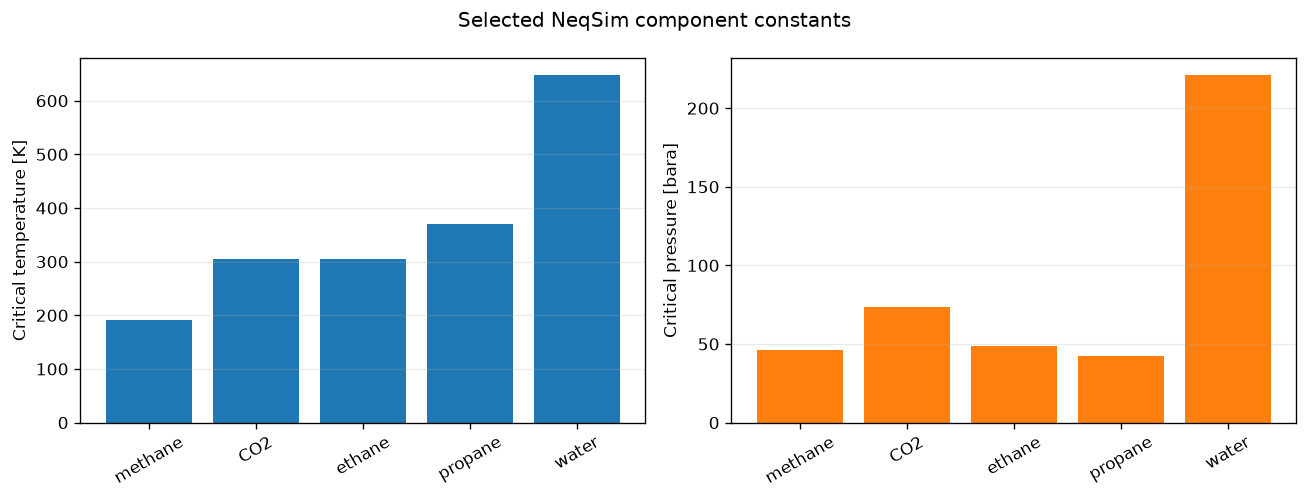

In [7]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].bar(
    component_properties["NAME"],
    component_properties["critical temperature [K]"],
    color="tab:blue",
)
axes[0].set_ylabel("Critical temperature [K]")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(
    component_properties["NAME"],
    component_properties["critical pressure [bara]"],
    color="tab:orange",
)
axes[1].set_ylabel("Critical pressure [bara]")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", alpha=0.25)

figure.suptitle("Selected NeqSim component constants")
figure.tight_layout()
plt.show()

## Cross-check the database against a live fluid

Creating an SRK system loads component parameters into runtime objects. We compare the
database values for methane and carbon dioxide with their getters. Exact agreement after
unit conversion verifies both our interpretation and the active parameter source.

This is a useful regression check after changing a NeqSim version or controlled parameter
set: it detects unit mistakes before they propagate into phase or process calculations.

In [8]:
audit_fluid = jneqsim.thermo.system.SystemSrkEos(300.0, 50.0)
audit_fluid.addComponent("methane", 0.8)
audit_fluid.addComponent("CO2", 0.2)
audit_fluid.setMixingRule("classic")
audit_fluid.init(0)

audit_rows = []

for component_name in ["methane", "CO2"]:
    database_row = component_properties.loc[
        component_properties["NAME"] == component_name
    ].iloc[0]
    runtime_component = audit_fluid.getComponent(component_name)
    audit_rows.append(
        {
            "component": component_name,
            "Tc residual [K]": (
                runtime_component.getTC()
                - database_row["critical temperature [K]"]
            ),
            "Pc residual [bara]": (
                runtime_component.getPC()
                - database_row["critical pressure [bara]"]
            ),
            "molar-mass residual [kg/mol]": (
                runtime_component.getMolarMass()
                - database_row["molar mass [kg/mol]"]
            ),
            "acentric-factor residual [-]": (
                runtime_component.getAcentricFactor()
                - database_row["acentric factor [-]"]
            ),
        }
    )

runtime_audit = pd.DataFrame(audit_rows)
runtime_audit

## Binary-interaction parameters

For a conventional quadratic mixing rule, the cross-attraction term is commonly written

$$
a_{\mathrm{mix}} = \sum_i \sum_j x_i x_j \sqrt{a_i a_j}(1-k_{ij})
$$

Here $x_i$ is component $i$'s mole fraction, $a_i$ is its pure-component attraction
parameter, and $k_{ij}$ is a dimensionless fitted binary-interaction parameter. A larger
positive $k_{ij}$ weakens the unlike-pair attraction in this formulation.

Interaction-table ordering is not guaranteed, so the read-only query checks both
`methane/CO2` and `CO2/methane` orientations.

In [9]:
interaction_columns = ["COMP1", "COMP2", "KIJSRK", "KIJPR"]
interaction_query = (
    "SELECT COMP1, COMP2, KIJSRK, KIJPR FROM inter "
    "WHERE (COMP1='methane' AND COMP2='CO2') "
    "OR (COMP1='CO2' AND COMP2='methane')"
)
interaction_result = database.getResultSet(interaction_query)
interaction_table = result_set_to_frame(
    interaction_result,
    interaction_columns,
)
interaction_table["KIJSRK"] = interaction_table["KIJSRK"].astype(float)
interaction_table["KIJPR"] = interaction_table["KIJPR"].astype(float)

database_kij_srk = float(interaction_table.iloc[0]["KIJSRK"])
runtime_kij_srk = float(
    audit_fluid.getPhase(0)
    .getMixingRule()
    .getBinaryInteractionParameter(0, 1)
)

interaction_table.assign(**{"runtime KIJSRK [-]": runtime_kij_srk})

## Baseline flash and phase-aware properties

We now solve a methane–carbon-dioxide mixture at 280 K and 50 bara. `TPflash` enforces
temperature, pressure, material conservation, and phase equilibrium. The model choice,
composition, and interaction data jointly determine phase count, compressibility factor
$Z$, and density in $\mathrm{kg/m^3}$.

This state is deliberately single-phase, making the subsequent $k_{ij}$ sensitivity easy
to interpret without discontinuities caused by phase appearance.

In [10]:
def make_binary_fluid(temperature_k, pressure_bara, kij=None):
    fluid = jneqsim.thermo.system.SystemSrkEos(
        temperature_k,
        pressure_bara,
    )
    fluid.addComponent("methane", 0.8)
    fluid.addComponent("CO2", 0.2)
    fluid.setMixingRule("classic")

    if kij is not None:
        for phase_index in range(fluid.getMaxNumberOfPhases()):
            mixing_rule = fluid.getPhase(phase_index).getMixingRule()
            mixing_rule.setBinaryInteractionParameter(0, 1, kij)
            mixing_rule.setBinaryInteractionParameter(1, 0, kij)

    TPflash(fluid)
    fluid.initPhysicalProperties()
    return fluid


baseline_fluid = make_binary_fluid(280.0, 50.0)
baseline_state = pd.DataFrame(
    {
        "quantity": ["temperature", "pressure", "phases", "density", "Z"],
        "value": [
            baseline_fluid.getTemperature("K"),
            baseline_fluid.getPressure("bara"),
            baseline_fluid.getNumberOfPhases(),
            baseline_fluid.getDensity("kg/m3"),
            baseline_fluid.getZ(),
        ],
        "unit": ["K", "bara", "-", "kg/m3", "-"],
    }
)
baseline_state

## Sensitivity without global database mutation

To study parameter uncertainty safely, each scenario creates a new fluid and changes
$k_{ij}$ only on that fluid's mixing-rule objects. The embedded tables remain untouched.

This is a sensitivity screen, not parameter regression. A defensible fitted value needs
documented experimental data, objective functions, uncertainty analysis, and validation
outside the calibration set.

In [11]:
kij_values = np.linspace(0.0, 0.15, 7)
sensitivity_rows = []

for kij_value in kij_values:
    scenario_fluid = make_binary_fluid(
        temperature_k=280.0,
        pressure_bara=50.0,
        kij=float(kij_value),
    )
    sensitivity_rows.append(
        {
            "KIJSRK [-]": float(kij_value),
            "density [kg/m3]": scenario_fluid.getDensity("kg/m3"),
            "Z [-]": scenario_fluid.getZ(),
            "phase count [-]": scenario_fluid.getNumberOfPhases(),
        }
    )

kij_sensitivity = pd.DataFrame(sensitivity_rows)
kij_sensitivity.round(6)

## Engineering interpretation of $k_{ij}$

At this gas-like state, increasing positive $k_{ij}$ reduces unlike attraction. The
calculated density falls and $Z$ rises monotonically. The effect is measurable but modest,
which is typical of a local sensitivity away from a phase boundary.

Near dew points, critical regions, or liquid-rich states, the response can be stronger
and non-linear. Never extrapolate this trend to a different composition or operating
region without rerunning the phase-equilibrium calculation.

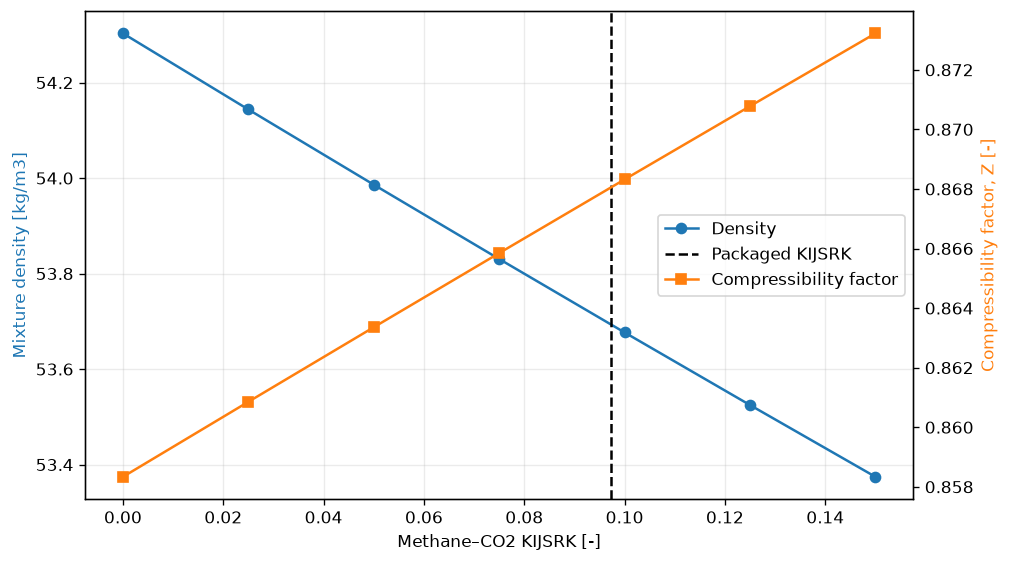

In [12]:
figure, density_axis = plt.subplots(figsize=(8.5, 4.8))
z_axis = density_axis.twinx()

density_axis.plot(
    kij_sensitivity["KIJSRK [-]"],
    kij_sensitivity["density [kg/m3]"],
    marker="o",
    color="tab:blue",
    label="Density",
)
z_axis.plot(
    kij_sensitivity["KIJSRK [-]"],
    kij_sensitivity["Z [-]"],
    marker="s",
    color="tab:orange",
    label="Compressibility factor",
)
density_axis.axvline(
    database_kij_srk,
    color="black",
    linestyle="--",
    label="Packaged KIJSRK",
)
density_axis.set_xlabel("Methane–CO2 KIJSRK [-]")
density_axis.set_ylabel("Mixture density [kg/m3]", color="tab:blue")
z_axis.set_ylabel("Compressibility factor, Z [-]", color="tab:orange")
density_axis.grid(alpha=0.25)

handles_1, labels_1 = density_axis.get_legend_handles_labels()
handles_2, labels_2 = z_axis.get_legend_handles_labels()
density_axis.legend(handles_1 + handles_2, labels_1 + labels_2, loc="center right")
figure.tight_layout()
plt.show()

## Pressure sensitivity using the packaged parameter set

The next screen keeps composition, temperature, model, and database parameters fixed
while pressure changes. Density should increase with pressure for a stable gas. The
compressibility factor reveals the growing departure from ideal-gas behaviour.

This sweep also demonstrates the solver workflow: construct a fresh system, load the
model parameters, execute `TPflash`, initialize physical properties, and record only
finite, unit-labelled outputs.

In [13]:
pressure_values_bara = np.linspace(10.0, 100.0, 10)
pressure_rows = []

for pressure_bara in pressure_values_bara:
    pressure_fluid = make_binary_fluid(
        temperature_k=300.0,
        pressure_bara=float(pressure_bara),
    )
    pressure_rows.append(
        {
            "pressure [bara]": float(pressure_bara),
            "density [kg/m3]": pressure_fluid.getDensity("kg/m3"),
            "Z [-]": pressure_fluid.getZ(),
            "phase count [-]": pressure_fluid.getNumberOfPhases(),
        }
    )

pressure_sensitivity = pd.DataFrame(pressure_rows)
pressure_sensitivity.round(5)

## Visual pressure check

The smooth, monotonic density curve is a useful numerical and physical check. A jump
would warrant inspection for phase appearance, convergence problems, or unintended model
changes. The displayed phase count is also asserted later rather than assumed.

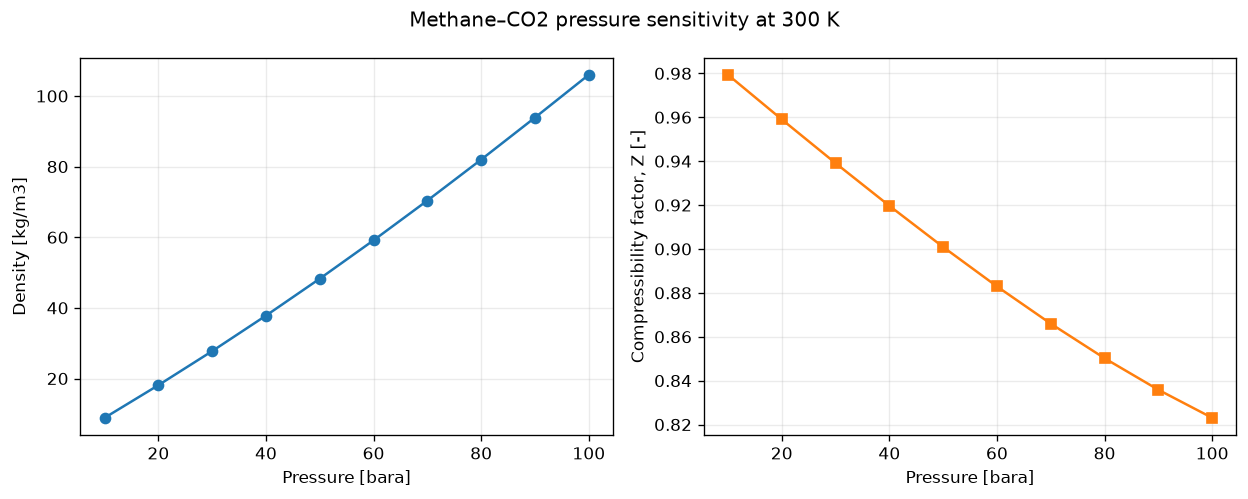

In [14]:
figure, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))

axes[0].plot(
    pressure_sensitivity["pressure [bara]"],
    pressure_sensitivity["density [kg/m3]"],
    marker="o",
)
axes[0].set_xlabel("Pressure [bara]")
axes[0].set_ylabel("Density [kg/m3]")
axes[0].grid(alpha=0.25)

axes[1].plot(
    pressure_sensitivity["pressure [bara]"],
    pressure_sensitivity["Z [-]"],
    marker="s",
    color="tab:orange",
)
axes[1].set_xlabel("Pressure [bara]")
axes[1].set_ylabel("Compressibility factor, Z [-]")
axes[1].grid(alpha=0.25)

figure.suptitle("Methane–CO2 pressure sensitivity at 300 K")
figure.tight_layout()
plt.show()

## Connect the model to a compressor

A steady adiabatic compressor raises the stream pressure from 50 to 100 bara with an
isentropic efficiency of 75%. NeqSim uses the database-backed SRK fluid in the inlet
stream, solves the isentropic reference state, and then determines the real outlet.

For mass flow $\dot m$ and specific enthalpy $h$, the steady energy relation is

$$
\dot W = \dot m(h_{\mathrm{out}}-h_{\mathrm{in}})
$$

where $\dot W$ is compressor power in kW when the enthalpy-flow difference is in kW.
Heat loss, mechanical loss beyond the specified efficiency, and pressure drop outside the
compressor are neglected.

In [15]:
clearProcess()

process_fluid = make_binary_fluid(300.0, 50.0)
process_fluid.setTotalFlowRate(2.0, "kg/sec")

feed_stream = stream("database-backed feed", process_fluid)
gas_compressor = compressor(
    "methane-CO2 compressor",
    feed_stream,
    100.0,
)
gas_compressor.setIsentropicEfficiency(0.75)
runProcess()

outlet_stream = gas_compressor.getOutletStream()
compressor_results = pd.DataFrame(
    {
        "quantity": [
            "inlet pressure",
            "outlet pressure",
            "inlet temperature",
            "outlet temperature",
            "inlet mass flow",
            "outlet mass flow",
            "compressor power",
        ],
        "value": [
            feed_stream.getPressure("bara"),
            outlet_stream.getPressure("bara"),
            feed_stream.getTemperature("K"),
            outlet_stream.getTemperature("K"),
            feed_stream.getFlowRate("kg/sec"),
            outlet_stream.getFlowRate("kg/sec"),
            gas_compressor.getPower("kW"),
        ],
        "unit": ["bara", "bara", "K", "K", "kg/s", "kg/s", "kW"],
    }
)
compressor_results.round(6)

## Independent validation and focused assertions

The checks below cover provenance, schema interpretation, runtime parameter loading,
finite properties, expected parameter trends, phase stability, and compressor mass and
energy behaviour. Tight equality checks are appropriate for values loaded directly from
the same packaged database; looser engineering tolerances are used for calculated states.

In [16]:
maximum_runtime_residual = runtime_audit.drop(columns="component").abs().to_numpy().max()
mass_residual_kg_s = (
    outlet_stream.getFlowRate("kg/sec")
    - feed_stream.getFlowRate("kg/sec")
)
enthalpy_power_kw = (
    outlet_stream.getFluid().getEnthalpy("kJ/kg")
    - feed_stream.getFluid().getEnthalpy("kJ/kg")
) * feed_stream.getFlowRate("kg/sec")
energy_residual_kw = gas_compressor.getPower("kW") - enthalpy_power_kw

assert database_type == "H2"
assert len(component_names) > 200
assert len(component_properties) == len(selected_components)
assert (component_properties["molar mass [kg/mol]"] > 0.0).all()
assert (component_properties["critical temperature [K]"] > 0.0).all()
assert (component_properties["critical pressure [bara]"] > 0.0).all()
assert maximum_runtime_residual < 1.0e-12
assert abs(database_kij_srk - runtime_kij_srk) < 1.0e-12
assert baseline_fluid.getNumberOfPhases() == 1
assert np.isfinite(kij_sensitivity.select_dtypes("number").to_numpy()).all()
assert (kij_sensitivity["phase count [-]"] == 1).all()
assert np.all(np.diff(kij_sensitivity["density [kg/m3]"]) < 0.0)
assert np.all(np.diff(kij_sensitivity["Z [-]"]) > 0.0)
assert np.all(np.diff(pressure_sensitivity["density [kg/m3]"]) > 0.0)
assert (pressure_sensitivity["phase count [-]"] == 1).all()
assert gas_compressor.getPower("kW") > 0.0
assert outlet_stream.getTemperature("K") > feed_stream.getTemperature("K")
assert abs(mass_residual_kg_s) < 1.0e-12
assert abs(energy_residual_kw) < 1.0e-6

validation_summary = pd.DataFrame(
    {
        "check": [
            "maximum loaded-parameter residual",
            "database/runtime KIJSRK residual",
            "compressor mass residual",
            "compressor energy residual",
        ],
        "value": [
            maximum_runtime_residual,
            database_kij_srk - runtime_kij_srk,
            mass_residual_kg_s,
            energy_residual_kw,
        ],
        "unit": ["mixed SI", "-", "kg/s", "kW"],
    }
)
print("All 19 engineering checks passed.")
print(validation_summary.to_string(index=False))
validation_summary

All 19 engineering checks passed.
                            check  value     unit
maximum loaded-parameter residual    0.0 mixed SI
 database/runtime KIJSRK residual    0.0        -
         compressor mass residual    0.0     kg/s
       compressor energy residual    0.0       kW


## Close resources, limitations, and troubleshooting

The database is closed explicitly after all result sets have been copied.

**Limitations.** Packaged parameters are general-purpose starting points, not a guarantee
of accuracy for every composition, pressure, temperature, electrolyte, association, or
near-critical problem. Validate the selected model against traceable laboratory or plant
data. A binary parameter is model-specific: an SRK value is not automatically valid for
PR, CPA, or another mixing rule.

**Troubleshooting.** If a component is unavailable, check its exact NeqSim name before
querying. If a query column fails, inspect the schema for the installed release instead of
guessing. If a flash changes phase count, treat property trends piecewise and inspect each
phase. Never repair a teaching runtime by downloading replacement tables or calling global
table-write methods.

In [17]:
database.close()

final_metrics = pd.DataFrame(
    {
        "metric": [
            "packaged KIJSRK",
            "baseline density",
            "compressor outlet temperature",
            "compressor power",
        ],
        "value": [
            database_kij_srk,
            baseline_fluid.getDensity("kg/m3"),
            outlet_stream.getTemperature("K"),
            gas_compressor.getPower("kW"),
        ],
        "unit": ["-", "kg/m3", "K", "kW"],
    }
)
print(final_metrics.round(6).to_string(index=False))
final_metrics.round(6)

                       metric      value  unit
              packaged KIJSRK   0.097300     -
             baseline density  53.693256 kg/m3
compressor outlet temperature 367.808770     K
             compressor power 211.698321    kW


## Summary, exercises, and references

You inspected NeqSim's packaged H2 database without changing it, converted component data
to explicit SI units, proved that live SRK objects load the same values, matched the
methane–CO2 interaction parameter, quantified a local $k_{ij}$ sensitivity, and closed a
database-backed compressor calculation.

**Further exercises**

1. Repeat the audit for nitrogen–methane and compare the SRK and PR interaction columns.
2. Move the methane–CO2 state toward its phase boundary and explain why sensitivity grows.
3. Compare SRK with an association-aware model for a water-rich mixture using validated data.
4. Export the labelled audit table with package and runtime versions as model provenance.

**Authoritative references**

- [NeqSim thermodynamic-model guidance](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html)
- [Reading fluid properties](https://equinor.github.io/neqsim/thermo/reading_fluid_properties.html)
- [NeqSim process simulation](https://equinor.github.io/neqsim/process/)
- [NeqSimDataBase source](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/util/database/NeqSimDataBase.java)

For parameter regression or controlled custom-database work, use versioned inputs, backups,
tests, and reviewable code outside a shared teaching runtime.